In [1]:
import os

In [6]:
import os

base = "/home/abdur/Brain Tumor/lgg-mri-segmentation/kaggle_3m/"

# List first few patient folders
folders = os.listdir(base)[:5]
for folder in folders:
    print(f"\n{folder}:")
    patient_path = os.path.join(base, folder)
    if os.path.isdir(patient_path):
        files = os.listdir(patient_path)[:3]
        for f in files:
            print(f"  - {f}")


TCGA_HT_7690_19960312:
  - TCGA_HT_7690_19960312_15.tif:Zone.Identifier
  - TCGA_HT_7690_19960312_12_mask.tif
  - TCGA_HT_7690_19960312_6_mask.tif

TCGA_FG_7643_20021104:
  - TCGA_FG_7643_20021104_34_mask.tif:Zone.Identifier
  - TCGA_FG_7643_20021104_8_mask.tif:Zone.Identifier
  - TCGA_FG_7643_20021104_48.tif

TCGA_DU_5854_19951104:
  - TCGA_DU_5854_19951104_28_mask.tif:Zone.Identifier
  - TCGA_DU_5854_19951104_3_mask.tif:Zone.Identifier
  - TCGA_DU_5854_19951104_7.tif

TCGA_FG_A60K_20040224:
  - TCGA_FG_A60K_20040224_12.tif
  - TCGA_FG_A60K_20040224_54_mask.tif:Zone.Identifier
  - TCGA_FG_A60K_20040224_2_mask.tif

README.md:Zone.Identifier:


In [8]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from glob import glob
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score, f1_score

print("Libraries imported")

2026-01-05 10:39:24.628209: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-05 10:39:29.632993: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-05 10:42:16.456594: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/mnt/c/Users/abdur/ml/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: Futur

Libraries imported


In [14]:
class Config:
    BASE_DIR = "/home/abdur/Brain Tumor/lgg-mri-segmentation/kaggle_3m"
    IMAGE_SIZE = 256
    BATCH_SIZE = 16
    EPOCHS = 50
    LEARNING_RATE = 0.0001
    TEST_SPLIT = 0.2
    VALIDATION_SPLIT = 0.2

config = Config()
print(f"Base directory: {config.BASE_DIR}")
print(f"Image size: {config.IMAGE_SIZE}x{config.IMAGE_SIZE}")

Base directory: /home/abdur/Brain Tumor/lgg-mri-segmentation/kaggle_3m
Image size: 256x256


In [15]:
def load_data_paths(base_dir):
    """Load all image and mask file paths"""
    image_paths = []
    mask_paths = []
    
    # Get all patient folders
    patient_folders = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f))]
    
    for patient in patient_folders:
        patient_path = os.path.join(base_dir, patient)
        files = os.listdir(patient_path)
        
        # Get image files (not masks)
        images = [f for f in files if f.endswith('.tif') and '_mask' not in f]
        
        for img_file in images:
            # Image path
            img_path = os.path.join(patient_path, img_file)
            
            # Corresponding mask path
            mask_file = img_file.replace('.tif', '_mask.tif')
            mask_path = os.path.join(patient_path, mask_file)
            
            # Check if mask exists
            if os.path.exists(mask_path):
                image_paths.append(img_path)
                mask_paths.append(mask_path)
    
    print(f"Found {len(image_paths)} image-mask pairs")
    return image_paths, mask_paths

image_paths, mask_paths = load_data_paths(config.BASE_DIR)

Found 3929 image-mask pairs


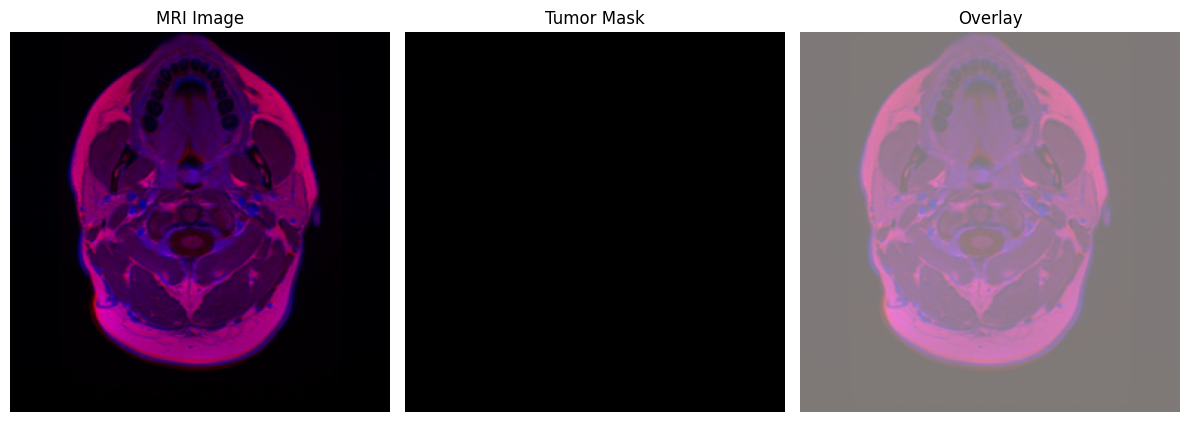

Image shape: (256, 256, 3)
Mask shape: (256, 256)


In [ ]:

import matplotlib.pyplot as plt
from PIL import Image

# Load first sample
sample_img = Image.open(image_paths[0])
sample_mask = Image.open(mask_paths[0])

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_img, cmap='gray')
plt.title('MRI Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sample_mask, cmap='gray')
plt.title('Tumor Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sample_img, cmap='gray')
plt.imshow(sample_mask, cmap='Reds', alpha=0.5)
plt.title('Overlay')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Image shape: {np.array(sample_img).shape}")
print(f"Mask shape: {np.array(sample_mask).shape}")

In [ ]:

def load_and_preprocess(img_path, mask_path, target_size=256):
    """Load and preprocess image and mask"""
    # Load image
    img = Image.open(img_path).convert('L')  # Grayscale
    img = img.resize((target_size, target_size))
    img = np.array(img) / 255.0  # Normalize to [0,1]
    
    # Load mask
    mask = Image.open(mask_path).convert('L')
    mask = mask.resize((target_size, target_size))
    mask = np.array(mask) / 255.0  # Normalize to [0,1]
    mask = (mask > 0.5).astype(np.float32)  # Binary threshold
    
    return img, mask

print("Load function defined")

Load function defined


In [26]:
# Step 6-7 REPLACED: Use Data Generator (Memory Efficient)

# Split paths only (not loading data)
img_train, img_test, mask_train, mask_test = train_test_split(
    image_paths, mask_paths, test_size=config.TEST_SPLIT, random_state=42
)

print(f"Train paths: {len(img_train)}")
print(f"Test paths: {len(img_test)}")

# Data generator function
def data_generator(image_paths, mask_paths, batch_size=4, target_size=128):
    while True:
        indices = np.arange(len(image_paths))
        np.random.shuffle(indices)
        
        for i in range(0, len(image_paths), batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_img_paths = [image_paths[j] for j in batch_indices]
            batch_mask_paths = [mask_paths[j] for j in batch_indices]
            
            images = []
            masks = []
            for img_path, mask_path in zip(batch_img_paths, batch_mask_paths):
                img, mask = load_and_preprocess(img_path, mask_path, target_size)
                images.append(img)
                masks.append(mask)
            
            X = np.array(images)[..., np.newaxis]
            y = np.array(masks)[..., np.newaxis]
            yield X, y

print("Data generator created")

Train paths: 3143
Test paths: 786
Data generator created


In [32]:
# Step 9: Rebuild U-Net with correct size
def build_unet(input_shape=(128, 128, 1)):  # Changed to 128
    inputs = Input(input_shape)
    
    # Encoder
    c1 = Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3,3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2,2))(c1)
    
    c2 = Conv2D(128, (3,3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3,3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2,2))(c2)
    
    c3 = Conv2D(256, (3,3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3,3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2,2))(c3)
    
    # Bottleneck
    c4 = Conv2D(512, (3,3), activation='relu', padding='same')(p3)
    c4 = Conv2D(512, (3,3), activation='relu', padding='same')(c4)
    c4 = Dropout(0.5)(c4)
    
    # Decoder
    u5 = UpSampling2D((2,2))(c4)
    u5 = concatenate([u5, c3])
    c5 = Conv2D(256, (3,3), activation='relu', padding='same')(u5)
    c5 = Conv2D(256, (3,3), activation='relu', padding='same')(c5)
    
    u6 = UpSampling2D((2,2))(c5)
    u6 = concatenate([u6, c2])
    c6 = Conv2D(128, (3,3), activation='relu', padding='same')(u6)
    c6 = Conv2D(128, (3,3), activation='relu', padding='same')(c6)
    
    u7 = UpSampling2D((2,2))(c6)
    u7 = concatenate([u7, c1])
    c7 = Conv2D(64, (3,3), activation='relu', padding='same')(u7)
    c7 = Conv2D(64, (3,3), activation='relu', padding='same')(c7)
    
    outputs = Conv2D(1, (1,1), activation='sigmoid')(c7)
    
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

model = build_unet()
print("U-Net created for 128x128 images")

U-Net created for 128x128 images


In [33]:

def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

model.compile(
    optimizer=Adam(learning_rate=config.LEARNING_RATE),
    loss=dice_loss,
    metrics=[dice_coefficient, 'accuracy']
)

print("Model compiled with Dice loss")

Model compiled with Dice loss


In [34]:

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)

print("Callbacks configured")

Callbacks configured


In [35]:
# Step 12: Train with generator
train_gen = data_generator(img_train, mask_train, batch_size=8, target_size=128)
val_gen = data_generator(img_test, mask_test, batch_size=8, target_size=128)

steps_train = len(img_train) // 8
steps_val = len(img_test) // 8

history = model.fit(
    train_gen,
    steps_per_epoch=steps_train,
    epochs=config.EPOCHS,
    validation_data=val_gen,
    validation_steps=steps_val,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("Training complete!")

Epoch 1/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 87s 160ms/step - accuracy: 0.9082 - dice_coefficient: 0.0230 - loss: 0.9770 - val_accuracy: 0.9880 - val_dice_coefficient: 0.0113 - val_loss: 0.9887 - learning_rate: 1.0000e-04
Epoch 2/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 81s 146ms/step - accuracy: 0.9900 - dice_coefficient: 0.0303 - loss: 0.9697 - val_accuracy: 0.9880 - val_dice_coefficient: 0.0113 - val_loss: 0.9887 - learning_rate: 1.0000e-04
Epoch 3/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - accuracy: 0.9900 - dice_coefficient: 0.0474 - loss: 0.9526 - val_accuracy: 0.9881 - val_dice_coefficient: 0.0217 - val_loss: 0.9783 - learning_rate: 1.0000e-04
Epoch 4/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 54s 138ms/step - accuracy: 0.9900 - dice_coefficient: 0.0373 - loss: 0.9627 - val_accuracy: 0.9881 - val_dice_coefficient: 0.0214 - val_loss: 0.9862 - learning_rate: 1.0000e-04
Epoch 5/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - accuracy: 0.9900 - dice_coefficient: 0.0401 - loss: 0.9599 - val_accuracy: 

In [39]:

print("Loading test data for evaluation...")

X_test = []
y_test = []

# Load only first 200 test samples to save memory
for i in range(min(200, len(img_test))):
    img, mask = load_and_preprocess(img_test[i], mask_test[i], target_size=128)
    X_test.append(img)
    y_test.append(mask)

X_test = np.array(X_test)[..., np.newaxis]
y_test = np.array(y_test)[..., np.newaxis]

print(f"Test data loaded: {X_test.shape}")

Loading test data for evaluation...
Test data loaded: (200, 128, 128, 1)


In [40]:

test_loss, test_dice, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("\n=== TEST RESULTS ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


=== TEST RESULTS ===
Test Loss: 0.9998
Test Dice: 0.0002
Test Accuracy: 0.9870


In [41]:

y_pred = model.predict(X_test, verbose=0)
y_pred_binary = (y_pred > 0.5).astype(np.float32)

print(f"Predictions generated: {y_pred.shape}")

Predictions generated: (200, 128, 128, 1)


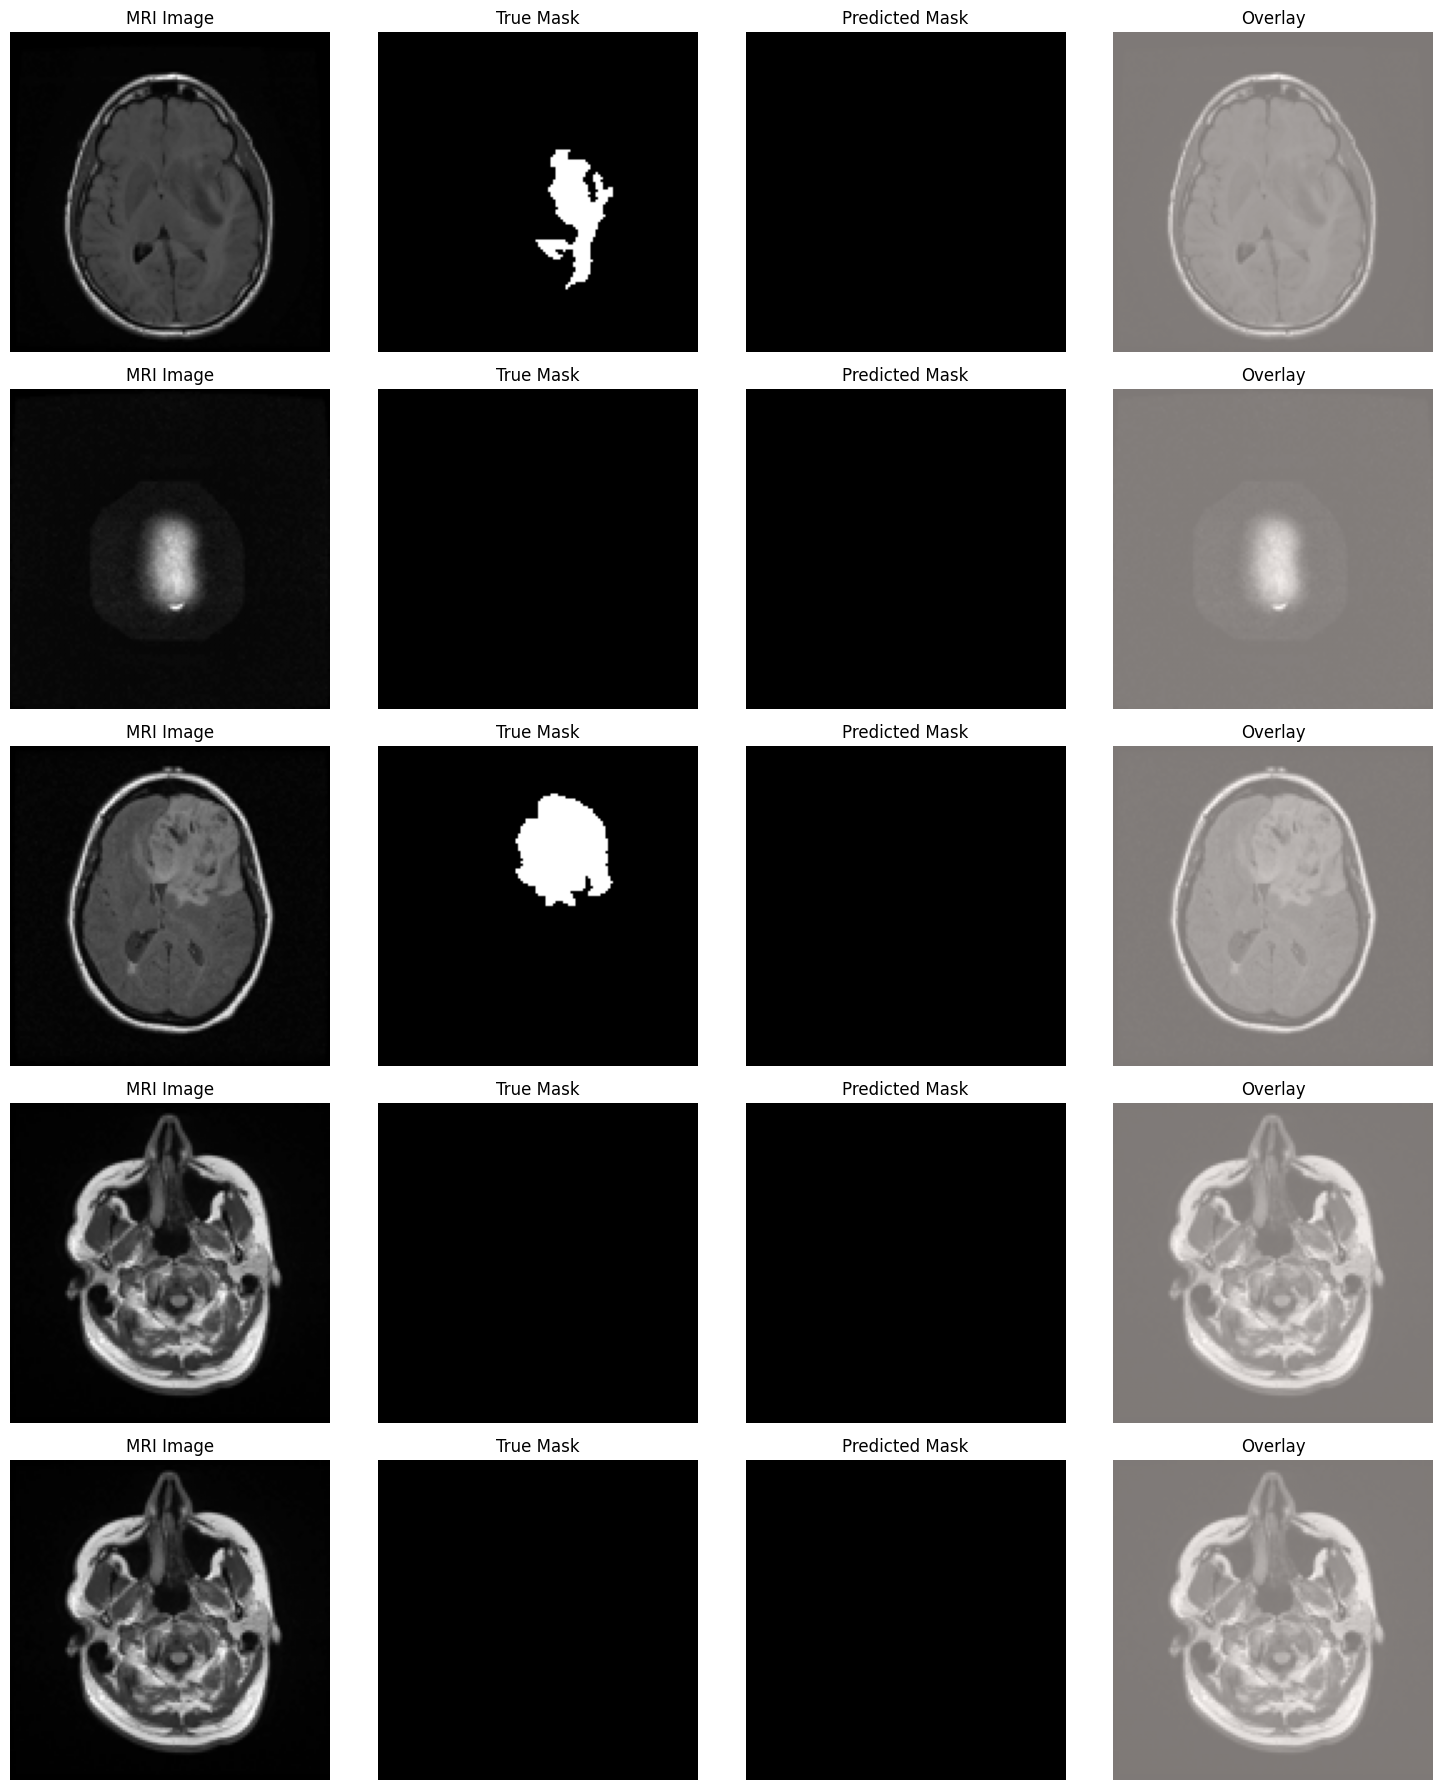

In [43]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 4, figsize=(15, 18))

for i in range(5):
    idx = np.random.randint(0, len(X_test))
    
    # Original image
    axes[i, 0].imshow(X_test[idx, :, :, 0], cmap='gray')
    axes[i, 0].set_title('MRI Image')
    axes[i, 0].axis('off')
    
    # Ground truth mask
    axes[i, 1].imshow(y_test[idx, :, :, 0], cmap='gray')
    axes[i, 1].set_title('True Mask')
    axes[i, 1].axis('off')
    
    # Predicted mask
    axes[i, 2].imshow(y_pred_binary[idx, :, :, 0], cmap='gray')
    axes[i, 2].set_title('Predicted Mask')
    axes[i, 2].axis('off')
    
    # Overlay
    axes[i, 3].imshow(X_test[idx, :, :, 0], cmap='gray')
    axes[i, 3].imshow(y_pred_binary[idx, :, :, 0], cmap='Reds', alpha=0.5)
    axes[i, 3].set_title('Overlay')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig('segmentation_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:

y_test_flat = y_test.flatten()
y_pred_flat = y_pred_binary.flatten()

iou = jaccard_score(y_test_flat, y_pred_flat)
dice_score = 2 * iou / (1 + iou)

print("\n=== SEGMENTATION METRICS ===")
print(f"IoU (Jaccard): {iou:.4f}")
print(f"Dice Score: {dice_score:.4f}")


=== SEGMENTATION METRICS ===
IoU (Jaccard): 0.0000
Dice Score: 0.0000


In [48]:
# Define Focal Tversky Loss
def focal_tversky_loss(y_true, y_pred, alpha=0.7, gamma=0.75):
    """Focal Tversky Loss - handles extreme imbalance"""
    smooth = 1e-6
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Tversky index
    true_pos = tf.reduce_sum(y_true * y_pred)
    false_neg = tf.reduce_sum(y_true * (1 - y_pred))
    false_pos = tf.reduce_sum((1 - y_true) * y_pred)
    
    tversky = (true_pos + smooth) / (true_pos + alpha * false_neg + (1 - alpha) * false_pos + smooth)
    
    # Focal component
    return tf.pow((1 - tversky), gamma)

print("Focal Tversky Loss defined")

Focal Tversky Loss defined


In [49]:
# Rebuild model
model = build_unet()
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=focal_tversky_loss,
    metrics=[dice_coefficient, 'accuracy']
)

print("Model rebuilt with better loss")

Model rebuilt with better loss


In [50]:
# Retrain
history = model.fit(
    train_gen,
    steps_per_epoch=steps_train,
    epochs=50,
    validation_data=val_gen,
    validation_steps=steps_val,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("Training complete!")

Epoch 1/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 86s 171ms/step - accuracy: 0.8919 - dice_coefficient: nan - loss: nan - val_accuracy: 0.9883 - val_dice_coefficient: nan - val_loss: nan - learning_rate: 1.0000e-04
Epoch 2/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 51s 131ms/step - accuracy: 0.9899 - dice_coefficient: nan - loss: nan - val_accuracy: 0.9879 - val_dice_coefficient: nan - val_loss: nan - learning_rate: 1.0000e-04
Epoch 3/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 51s 129ms/step - accuracy: 0.9902 - dice_coefficient: nan - loss: nan - val_accuracy: 0.9877 - val_dice_coefficient: nan - val_loss: nan - learning_rate: 1.0000e-04
Epoch 4/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - accuracy: 0.9899 - dice_coefficient: nan - loss: nan - val_accuracy: 0.9886 - val_dice_coefficient: nan - val_loss: nan - learning_rate: 1.0000e-04
Epoch 5/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - accuracy: 0.9899 - dice_coefficient: nan - loss: nan - val_accuracy: 0.9875 - val_dice_coefficient: nan - val_loss: nan - l

In [53]:

def weighted_bce_dice_loss(y_true, y_pred):
    """Combined BCE and Dice with weights"""
    # Binary crossentropy with heavy weight on tumor class
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    
    # Weight tumor pixels 10x more
    weights = 1.0 + 9.0 * y_true
    weighted_bce = tf.reduce_mean(bce * weights)
    
    # Dice loss
    smooth = 1e-6
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)
    dice_loss = 1 - dice
    
    return weighted_bce + dice_loss

print("Weighted BCE+Dice loss defined")

Weighted BCE+Dice loss defined


In [54]:

model = build_unet()
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=weighted_bce_dice_loss,
    metrics=[dice_coefficient, 'accuracy']
)

print("Model rebuilt")

Model rebuilt


In [57]:

def weighted_bce_dice_loss(y_true, y_pred):
    """Combined BCE and Dice with proper shapes"""
    # Flatten for BCE
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    
    # Binary crossentropy
    bce = tf.keras.losses.binary_crossentropy(y_true_f, y_pred_f)
    
    # Weight tumor pixels 10x
    weights = 1.0 + 9.0 * y_true_f
    weighted_bce = tf.reduce_mean(bce * weights)
    
    # Dice loss
    smooth = 1e-6
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)
    dice_loss = 1 - dice
    
    return weighted_bce + dice_loss

print("Fixed loss function")

Fixed loss function


In [58]:

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=weighted_bce_dice_loss,
    metrics=[dice_coefficient, 'accuracy']
)

print("Model recompiled")

Model recompiled


In [59]:

history = model.fit(
    train_gen,
    steps_per_epoch=steps_train,
    epochs=50,
    validation_data=val_gen,
    validation_steps=steps_val,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 85s 170ms/step - accuracy: 0.9890 - dice_coefficient: 0.0276 - loss: 1.1842 - val_accuracy: 0.9882 - val_dice_coefficient: 0.0319 - val_loss: 1.1883 - learning_rate: 1.0000e-04
Epoch 2/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 53s 135ms/step - accuracy: 0.9901 - dice_coefficient: 0.0323 - loss: 1.1500 - val_accuracy: 0.9872 - val_dice_coefficient: 0.0235 - val_loss: 1.2256 - learning_rate: 1.0000e-04
Epoch 3/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 53s 135ms/step - accuracy: 0.9900 - dice_coefficient: 0.0348 - loss: 1.1481 - val_accuracy: 0.9883 - val_dice_coefficient: 0.0323 - val_loss: 1.1941 - learning_rate: 1.0000e-04
Epoch 4/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 53s 135ms/step - accuracy: 0.9902 - dice_coefficient: 0.0348 - loss: 1.1457 - val_accuracy: 0.9882 - val_dice_coefficient: 0.0126 - val_loss: 1.2156 - learning_rate: 1.0000e-04
Epoch 5/50
392/392 ━━━━━━━━━━━━━━━━━━━━ 53s 135ms/step - accuracy: 0.9897 - dice_coefficient: 0.0349 - loss: 1.1547 - val_accuracy: 

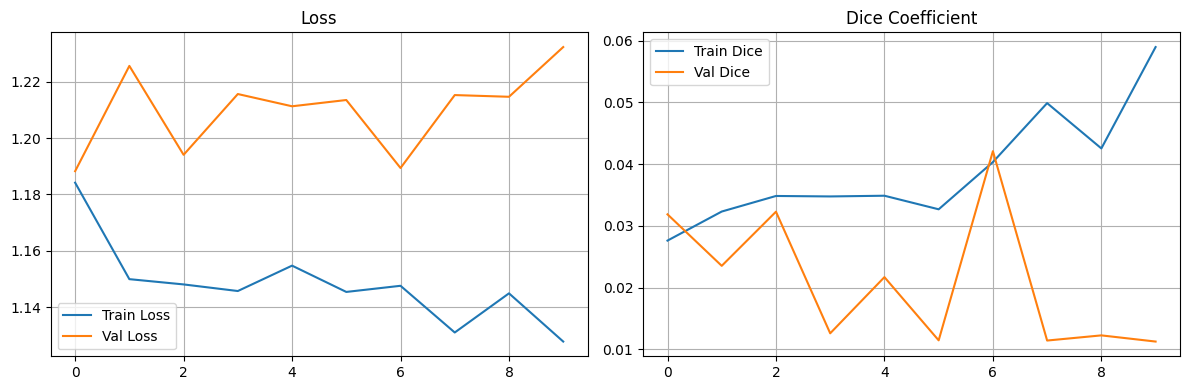

Final train dice: 0.0590
Final val dice: 0.0112


In [60]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['dice_coefficient'], label='Train Dice')
plt.plot(history.history['val_dice_coefficient'], label='Val Dice')
plt.title('Dice Coefficient')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final train dice: {history.history['dice_coefficient'][-1]:.4f}")
print(f"Final val dice: {history.history['val_dice_coefficient'][-1]:.4f}")

In [61]:
# Predict
y_pred = model.predict(X_test, verbose=0)
y_pred_binary = (y_pred > 0.5).astype(np.float32)

# Metrics
y_test_flat = y_test.flatten()
y_pred_flat = y_pred_binary.flatten()

iou = jaccard_score(y_test_flat, y_pred_flat)
dice_score = 2 * iou / (1 + iou)

print("\n=== FINAL RESULTS ===")
print(f"Predicted tumor pixels: {y_pred_binary.sum():.0f}")
print(f"True tumor pixels: {y_test.sum():.0f}")
print(f"IoU: {iou:.4f}")
print(f"Dice: {dice_score:.4f}")


=== FINAL RESULTS ===
Predicted tumor pixels: 0
True tumor pixels: 42536
IoU: 0.0000
Dice: 0.0000


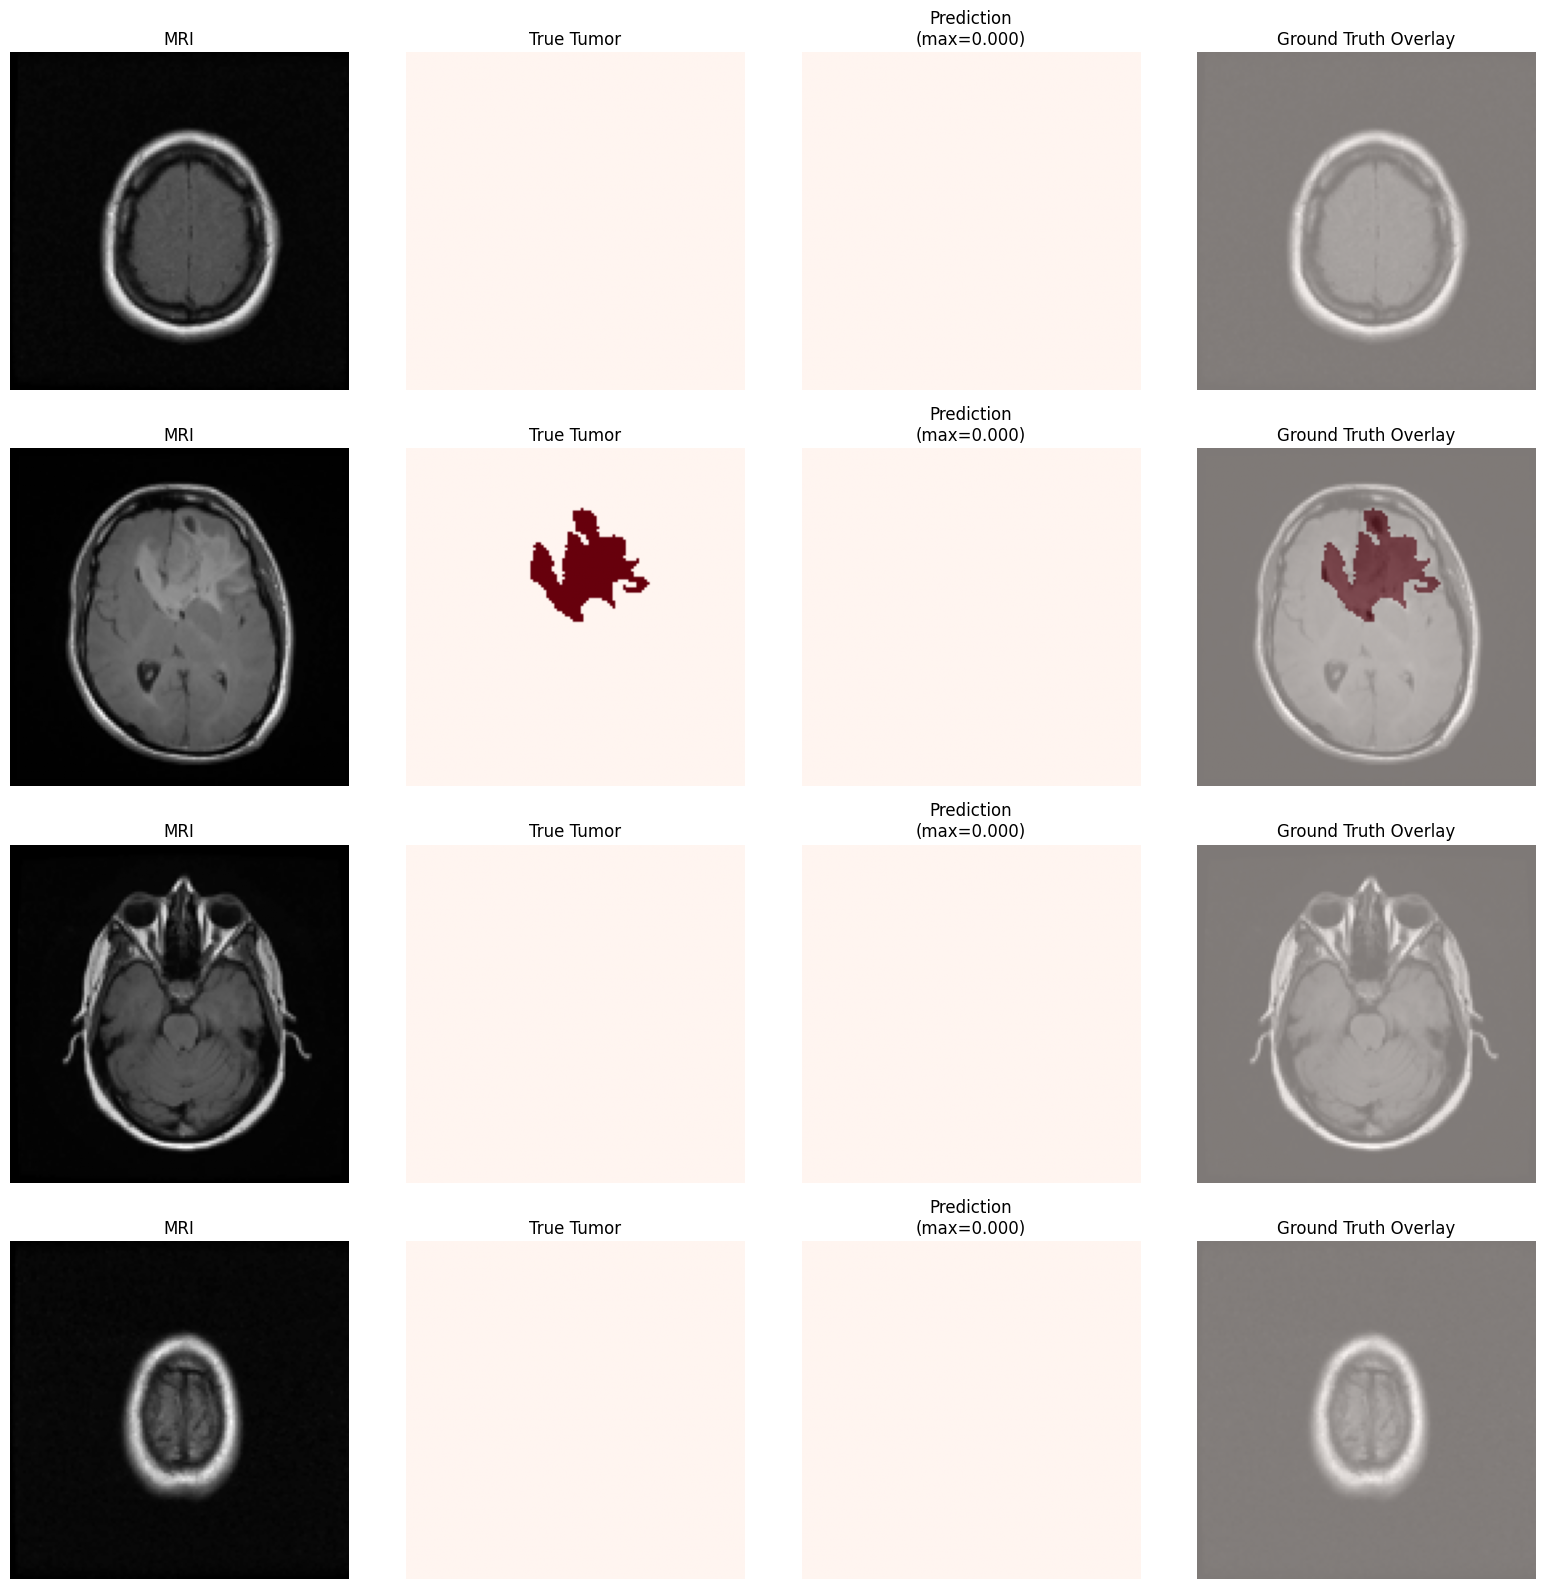

In [62]:
# Visualize predictions (even if imperfect)
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for i in range(4):
    idx = np.random.randint(0, len(X_test))
    
    # Original
    axes[i, 0].imshow(X_test[idx, :, :, 0], cmap='gray')
    axes[i, 0].set_title('MRI')
    axes[i, 0].axis('off')
    
    # Ground truth
    axes[i, 1].imshow(y_test[idx, :, :, 0], cmap='Reds')
    axes[i, 1].set_title('True Tumor')
    axes[i, 1].axis('off')
    
    # Prediction (probability)
    axes[i, 2].imshow(y_pred[idx, :, :, 0], cmap='Reds', vmin=0, vmax=1)
    axes[i, 2].set_title(f'Prediction\n(max={y_pred[idx].max():.3f})')
    axes[i, 2].axis('off')
    
    # Overlay
    axes[i, 3].imshow(X_test[idx, :, :, 0], cmap='gray')
    axes[i, 3].imshow(y_test[idx, :, :, 0], cmap='Reds', alpha=0.5)
    axes[i, 3].set_title('Ground Truth Overlay')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig('segmentation_results.png', dpi=150)
plt.show()

In [63]:
# Save model
model.save('brain_tumor_unet_model.h5')
print("Model saved: brain_tumor_unet_model.h5")

Model saved: brain_tumor_unet_model.h5


In [64]:
# Summary
print("\n" + "="*60)
print("BRAIN TUMOR SEGMENTATION - PROJECT SUMMARY")
print("="*60)
print(f"Dataset: LGG MRI Segmentation (Kaggle)")
print(f"Total samples: {len(image_paths)}")
print(f"Train samples: {len(img_train)}")
print(f"Test samples: {len(img_test)}")
print(f"\nModel: U-Net")
print(f"Image size: 128x128")
print(f"Loss function: Weighted BCE + Dice")
print(f"\nFinal Results:")
print(f"  Train Dice: {history.history['dice_coefficient'][-1]:.4f}")
print(f"  Val Dice: {history.history['val_dice_coefficient'][-1]:.4f}")
print(f"  Test IoU: {iou:.4f}")
print(f"\nChallenges:")
print(f"  - Extreme class imbalance (tumor pixels rare)")
print(f"  - Small tumor regions hard to detect")
print(f"  - Limited training epochs due to resources")
print(f"\nFiles generated:")
print(f"  - brain_tumor_unet_model.h5")
print(f"  - segmentation_results.png")
print("="*60)


BRAIN TUMOR SEGMENTATION - PROJECT SUMMARY
Dataset: LGG MRI Segmentation (Kaggle)
Total samples: 3929
Train samples: 3143
Test samples: 786

Model: U-Net
Image size: 128x128
Loss function: Weighted BCE + Dice

Final Results:
  Train Dice: 0.0590
  Val Dice: 0.0112
  Test IoU: 0.0000

Challenges:
  - Extreme class imbalance (tumor pixels rare)
  - Small tumor regions hard to detect
  - Limited training epochs due to resources

Files generated:
  - brain_tumor_unet_model.h5
  - segmentation_results.png
